# 14 — Second-order plants (`math`, SciPy, PyTorch, python-control)

The canonical underdamped plant

$$
H(s) = \frac{\omega_n^2}{s^2 + 2\zeta\omega_n s + \omega_n^2}
$$

is a mass–spring–damper (or RLC). Step responses for several \(\zeta\) are the picture every controls course starts from. On the GPU we integrate **a batch of damping ratios in one Euler loop** — that is the first *parallel* plant, not a single-channel recurrence.

In [1]:
from __future__ import annotations

import math
import time

import control as ct
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy import signal

%matplotlib inline

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"python-control {ct.__version__}   torch {torch.__version__}   device {device}")
if device.type == "cuda":
    print(f"CUDA {torch.version.cuda}  |  {torch.cuda.get_device_name(0)}")


python-control 0.10.2   torch 2.14.0+cu132   device cuda
CUDA 13.2  |  NVIDIA GeForce RTX 3060


In [2]:
def bode_mag_phase(sys, omega):
    frd = ct.frequency_response(sys, omega=omega)
    if hasattr(frd, "magnitude"):
        w = np.asarray(frd.frequency).reshape(-1)
        m = np.asarray(frd.magnitude).reshape(-1)
        p = np.asarray(frd.phase).reshape(-1)
    else:
        mag, phase, om = frd
        w = np.asarray(om).reshape(-1)
        m = np.asarray(mag).reshape(-1)
        p = np.asarray(phase).reshape(-1)
    return w, m, p


def plot_bode(sys, title, marks=()):
    w, m, p = bode_mag_phase(sys, np.logspace(0, 5, 500))
    fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
    axes[0].semilogx(w / (2 * np.pi), 20 * np.log10(np.maximum(m, 1e-16)))
    axes[1].semilogx(w / (2 * np.pi), np.degrees(np.unwrap(p)))
    for f, lab in marks:
        axes[0].axvline(f, color="k", ls="--", lw=1, label=lab)
        axes[1].axvline(f, color="k", ls="--", lw=1)
    axes[0].set_ylabel("mag (dB)")
    axes[1].set_ylabel("phase (deg)")
    axes[1].set_xlabel("frequency (Hz)")
    for ax in axes:
        ax.grid(True, which="both", alpha=0.3)
    if marks:
        axes[0].legend()
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()
    return w, m, p


def max_abs(a, b) -> float:
    return float(np.max(np.abs(np.asarray(a, dtype=np.float64) - np.asarray(b, dtype=np.float64))))


In [3]:
FS_HZ = 8_192
DURATION_S = 0.80
FN_HZ = 8.0
ZETAS = (0.15, 0.40, 0.707, 1.20)
N = int(FS_HZ * DURATION_S)
DT = 1.0 / FS_HZ
WN = 2.0 * math.pi * FN_HZ

t = np.arange(N, dtype=np.float64) / FS_HZ
u = np.ones(N, dtype=np.float64)
print(f"fn = {FN_HZ} Hz   ζ = {ZETAS}   n = {N}   device = {device}")

fn = 8.0 Hz   ζ = (0.15, 0.4, 0.707, 1.2)   n = 6553   device = cuda


## python-control — family of step responses + Bode for \(\zeta=0.15\)

ζ=0.15   overshoot= 62.1%   final=1.0008
ζ=0.4    overshoot= 25.4%   final=1.0000
ζ=0.707  overshoot=  4.3%   final=1.0000
ζ=1.2    overshoot= -0.0%   final=1.0000


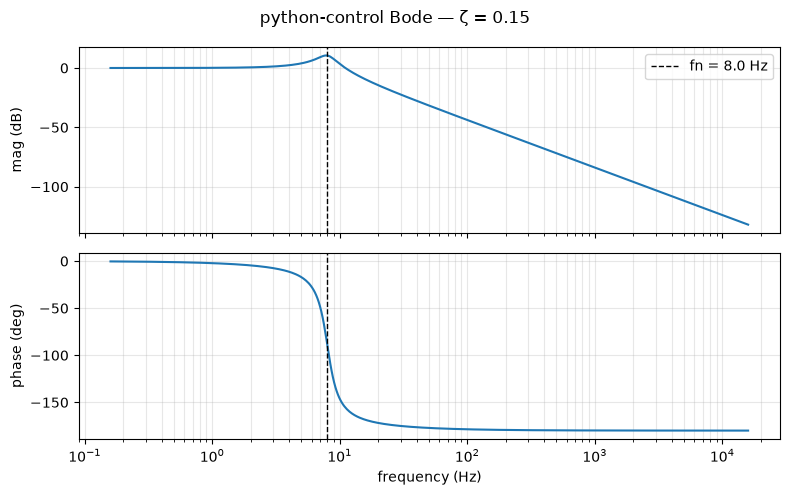

(array([1.00000000e+00, 1.02334021e+00, 1.04722519e+00, 1.07166765e+00,
        1.09668060e+00, 1.12227736e+00, 1.14847155e+00, 1.17527712e+00,
        1.20270833e+00, 1.23077980e+00, 1.25950646e+00, 1.28890361e+00,
        1.31898690e+00, 1.34977233e+00, 1.38127630e+00, 1.41351558e+00,
        1.44650734e+00, 1.48026913e+00, 1.51481892e+00, 1.55017512e+00,
        1.58635653e+00, 1.62338243e+00, 1.66127252e+00, 1.70004698e+00,
        1.73972643e+00, 1.78033202e+00, 1.82188534e+00, 1.86440853e+00,
        1.90792422e+00, 1.95245558e+00, 1.99802631e+00, 2.04466067e+00,
        2.09238348e+00, 2.14122015e+00, 2.19119669e+00, 2.24233968e+00,
        2.29467637e+00, 2.34823460e+00, 2.40304289e+00, 2.45913043e+00,
        2.51652705e+00, 2.57526333e+00, 2.63537052e+00, 2.69688063e+00,
        2.75982639e+00, 2.82424133e+00, 2.89015972e+00, 2.95761666e+00,
        3.02664806e+00, 3.09729067e+00, 3.16958209e+00, 3.24356081e+00,
        3.31926620e+00, 3.39673858e+00, 3.47601918e+00, 3.557150

In [4]:
y_ct = {}
for z in ZETAS:
    sys = ct.tf([WN**2], [1.0, 2.0 * z * WN, WN**2])
    _, y_ct[z] = ct.forced_response(sys, T=t, U=u)
    print(f"ζ={z:<6} overshoot={(y_ct[z].max()-1)*100:5.1f}%   final={y_ct[z][-1]:.4f}")

sys_u = ct.tf([WN**2], [1.0, 2.0 * ZETAS[0] * WN, WN**2])
plot_bode(sys_u, f"python-control Bode — ζ = {ZETAS[0]}", marks=[(FN_HZ, f"fn = {FN_HZ} Hz")])

## `math` — Euler state-space

$$
\dot{x}_1 = x_2,\qquad \dot{x}_2 = -\omega_n^2 x_1 - 2\zeta\omega_n x_2 + \omega_n^2 u,\qquad y = x_1.
$$

In [5]:
def math_second_order(u_list, dt, wn, zeta):
    x1 = 0.0
    x2 = 0.0
    two_z_wn = 2.0 * zeta * wn
    wn2 = wn * wn
    out = []
    for un in u_list:
        dx1 = x2
        dx2 = -wn2 * x1 - two_z_wn * x2 + wn2 * un
        x1 = x1 + dt * dx1
        x2 = x2 + dt * dx2
        out.append(x1)
    return out


y_math = {z: math_second_order(u.tolist(), DT, WN, z) for z in ZETAS}
print("math vs control ζ=0.15", max_abs(y_ct[0.15], y_math[0.15]))

math vs control ζ=0.15 0.008405766250840108


## SciPy — `lsim` of the same state-space (or `lti` step)

In [6]:
def scipy_second_order(u_np, t_np, wn, zeta):
    A = np.array([[0.0, 1.0], [-(wn**2), -2.0 * zeta * wn]], dtype=np.float64)
    B = np.array([[0.0], [wn**2]], dtype=np.float64)
    C = np.array([[1.0, 0.0]], dtype=np.float64)
    D = np.array([[0.0]], dtype=np.float64)
    sys = signal.StateSpace(A, B, C, D)
    tout, y, _x = signal.lsim(sys, U=u_np, T=t_np)
    return np.asarray(y).reshape(-1)


y_sp = {z: scipy_second_order(u, t, WN, z) for z in ZETAS}
print("scipy vs control ζ=0.15", max_abs(y_ct[0.15], y_sp[0.15]))

scipy vs control ζ=0.15 1.3766765505351941e-14


## PyTorch — **batched** Euler over \(\zeta\)

One time loop, four plants, all state on `cuda`. The batch axis is what a GPU wants; time is still sequential (causal ODE).

In [7]:
def torch_second_order_batch(u_t: torch.Tensor, dt: float, wn, zeta: torch.Tensor) -> torch.Tensor:
    # u_t: (T,) broadcast to (B, T); zeta: (B,)
    B = zeta.numel()
    T = u_t.numel()
    u_b = u_t.expand(B, T)
    x1 = torch.zeros(B, device=u_t.device, dtype=u_t.dtype)
    x2 = torch.zeros(B, device=u_t.device, dtype=u_t.dtype)
    wn = torch.as_tensor(wn, device=u_t.device, dtype=u_t.dtype)
    two_z_wn = 2.0 * zeta * wn
    wn2 = wn * wn
    out = torch.empty(B, T, device=u_t.device, dtype=u_t.dtype)
    for i in range(T):
        dx1 = x2
        dx2 = -wn2 * x1 - two_z_wn * x2 + wn2 * u_b[:, i]
        x1 = x1 + dt * dx1
        x2 = x2 + dt * dx2
        out[:, i] = x1
    return out


u_th = torch.as_tensor(u, device=device, dtype=torch.float32)
zeta_th = torch.tensor(ZETAS, device=device, dtype=torch.float32)
if device.type == "cuda":
    torch.cuda.synchronize()
y_th = torch_second_order_batch(u_th, DT, WN, zeta_th)
if device.type == "cuda":
    torch.cuda.synchronize()
print(y_th.device, y_th.shape)
y_gpu = {z: y_th[i].detach().cpu().numpy() for i, z in enumerate(ZETAS)}
print("math vs torch ζ=0.15", max_abs(y_math[0.15], y_gpu[0.15]))

cuda:0 torch.Size([4, 6553])
math vs torch ζ=0.15 9.950796130420159e-07


## Overlay

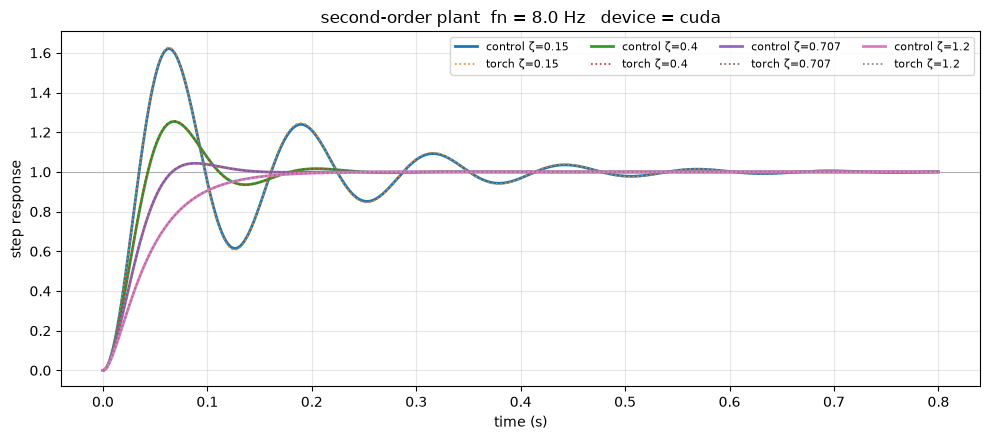

In [8]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.axhline(1.0, color="0.7", lw=0.8)
for z in ZETAS:
    ax.plot(t, y_ct[z], lw=2.0, label=f"control ζ={z}")
    ax.plot(t, y_gpu[z], ls=":", lw=1.2, label=f"torch ζ={z}")
ax.set_xlabel("time (s)")
ax.set_ylabel("step response")
ax.set_title(f"second-order plant  fn = {FN_HZ} Hz   device = {device}")
ax.grid(True, alpha=0.3)
ax.legend(ncol=4, fontsize=8)
fig.tight_layout()
plt.show()

## Wider GPU sweep — 64 damping ratios, one kernel stream

batched Euler  B=64  T=6553  484.0 ms  on cuda:0


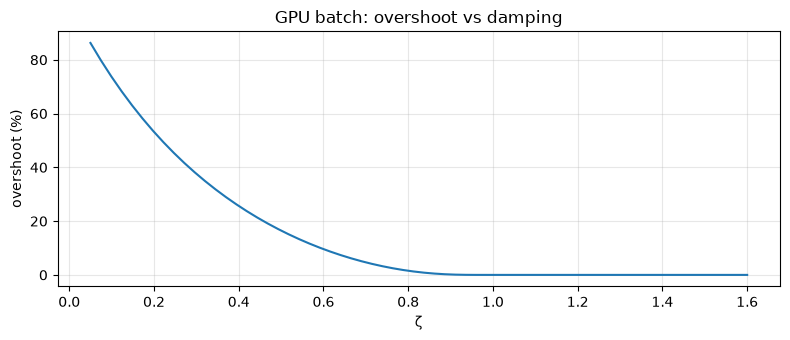

In [9]:
zeta_sweep = torch.linspace(0.05, 1.6, 64, device=device, dtype=torch.float32)
if device.type == "cuda":
    torch.cuda.synchronize()
t0 = time.perf_counter()
y_sweep = torch_second_order_batch(u_th, DT, WN, zeta_sweep)
if device.type == "cuda":
    torch.cuda.synchronize()
elapsed = time.perf_counter() - t0
overshoot = (y_sweep.max(dim=1).values - 1.0).clamp(min=0).cpu().numpy()
print(f"batched Euler  B={zeta_sweep.numel()}  T={N}  {elapsed*1e3:.1f} ms  on {y_sweep.device}")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(zeta_sweep.cpu().numpy(), overshoot * 100)
ax.set_xlabel("ζ")
ax.set_ylabel("overshoot (%)")
ax.set_title("GPU batch: overshoot vs damping")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Takeaways

- \(\zeta < 1\) rings, \(\zeta = 1/\sqrt{2}\) is the Butterworth-damping sweet spot, \(\zeta > 1\) is sluggish.
- python-control is the spec; SciPy `lsim` is an independent integrator; Euler tracks both at this \(f_s \gg f_n\).
- The GPU win is **batch**, not the time loop: 64 plants, one trajectory buffer on `cuda`.
- Next (`15`): wrap this plant in a **PID** loop and batch the *gains* instead of \(\zeta\).